# Thesis: Reclaimed Timber in Deep Generative Design

**Notebook:** c25_26_27_optimizer_workflow_with_cost_and_ILP  
**Author:** Jasper Cluistra | **Last Updated:** 2026-02-27

## Cost and ILP Optimization Workflow

Generate a cost matrix for the geometry using timber datasets, then use ILP to find the best assignments.

**Inputs:** CSV timber dataset, Digital geometry  
**Outputs:** Best match for each structural element

# IMPORTING

## Dataset

In [1]:
import config
import pandas as pd

testing = False
if testing:
    file_path = config.TIMBER_STOCK_PATH / 'complete_timber_small.csv'
else:
    file_path = config.TIMBER_STOCK_PATH / 'complete_timber.csv'

# Try common combinations
read_attempts = [
    {"sep": ",", "encoding": "utf-8"},
    {"sep": ";", "encoding": "utf-8"},
    {"sep": ",", "encoding": "latin1"},
    {"sep": ";", "encoding": "latin1"},
]

df_input_stock = None
for opts in read_attempts:
    try:
        df_try = pd.read_csv(file_path, **opts)  # type: ignore
        # Valid if we get more than 1 column
        if df_try.shape[1] > 1:
            df_input_stock = df_try
            print(f"Loaded with sep='{opts['sep']}' and encoding='{opts['encoding']}'")
            break
    except Exception:
        pass

if df_input_stock is None:
    raise ValueError("Could not parse CSV with tested delimiter/encoding combinations.")

# Clean column names
df_input_stock.columns = df_input_stock.columns.str.strip()

print("Detected columns:", df_input_stock.columns.tolist())
print(f"\nDataset contains {df_input_stock.shape[0]} elements\n")
display(df_input_stock.head())

System loaded successfully.

Code is running locally from: thesis_generative_timber
Data connected to OneDrive: 2.2 - 2.4

Loaded with sep=';' and encoding='utf-8'
Detected columns: ['Member_ID', 'State', 'Length', 'Depth', 'Width', 'f_mk', 'f_tk', 'E_modulus_eff', 'E_modulus_005', 'f_vk', 'f_c0k', 'k_density', 'mean_density', 'ECC', 'Origin_Country', 'Transport_Dist', 'EmissionFactor', 'ProcessingFactor']

Dataset contains 324 elements



,Member_ID,State,Length,Depth,Width,f_mk,f_tk,E_modulus_eff,E_modulus_005,f_vk,f_c0k,k_density,mean_density,ECC,Origin_Country,Transport_Dist,EmissionFactor,ProcessingFactor
0,NS_00000,0,1500.0,100.0,38.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Finland,1688.82,0.1743,0
1,NS_00001,0,1500.0,100.0,50.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Germany,341.61,0.1724,0
2,NS_00002,0,1500.0,100.0,63.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Poland,816.74,0.1778,0
3,NS_00003,0,1500.0,100.0,75.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Finland,1707.28,0.1771,0
4,NS_00004,0,1500.0,100.0,100.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Belgium,145.43,0.1777,0


## Search space

Search space imported from geometry script. Random design selected as starting point.

In [2]:
import json
import config

json_path = config.DATA_IO_PATH / "search_space.json"

with open(json_path, "r") as f:
    optimizer_search_space = json.load(f)

print(f"Search space loaded. The optimizer can control {len(optimizer_search_space)} parameters.")


Search space loaded. The optimizer can control 18 parameters.


Generates random design parameters, translates to 3D geometry, and runs inference pipeline.

# GEOMETRY

## Random geometry

In [11]:
import json
import random
import c11_params
import numpy as np
from geometry import generate_sample_vertices
from reconstruction import reconstruct_edges

# Generate random design parameters
def get_random_design(json_path):
    """Read search space and sample random value for each variable."""
    with open(json_path, 'r') as f:
        search_space = json.load(f)
    random_params = {}
    for var_name, rules in search_space.items():
        if rules['type'] == 'continuous':
            random_params[var_name] = random.uniform(rules['min'], rules['max'])
        elif rules['type'] == 'discrete':
            random_params[var_name] = random.choice(rules['options'])
    return random_params

# Generate geometry
my_random_design = get_random_design(json_path)
vertices_list = generate_sample_vertices(sample_id=0, params=my_random_design)
df_vertices = pd.DataFrame(vertices_list)
df_edges = reconstruct_edges(c11_params.GRID_CELLS_X, c11_params.GRID_CELLS_Y)

# Build compact geometry table with member lengths [m]
vertex_lookup = df_vertices.set_index("vertex_index")[["x", "y", "z"]].to_dict("index")

def _to_vertex_key(v):
    v_str = str(v)
    return v_str if v_str.startswith("v") else f"v{v_str}"

def _edge_length_m(v1, v2):
    p1 = vertex_lookup[_to_vertex_key(v1)]
    p2 = vertex_lookup[_to_vertex_key(v2)]
    return float(np.linalg.norm([
        p2["x"] - p1["x"],
        p2["y"] - p1["y"],
        p2["z"] - p1["z"],
    ]))

df_geometry_overview = df_edges.copy()
df_geometry_overview["length_m"] = df_geometry_overview.apply(
    lambda r: round(_edge_length_m(r["V1"], r["V2"]), 3), axis=1
)

print(f"Geometry: {len(df_vertices)} nodes, {len(df_edges)} members")
print(
    f"Length range [m]: {df_geometry_overview['length_m'].min():.3f}"
    f" - {df_geometry_overview['length_m'].max():.3f}"
)
display(df_geometry_overview[["edge_id", "V1", "V2", "length_m"]].head(12))

Geometry: 13 nodes, 32 members
Length range [m]: 1.786 - 4.125


,edge_id,V1,V2,length_m
0,e0,0,1,3.000
1,e1,1,2,3.000
2,e2,3,4,3.824
3,e3,4,5,2.704
4,e4,6,7,2.625
5,e5,7,8,3.375
6,e6,0,3,2.625
7,e7,1,4,3.457
8,e8,2,5,1.875
9,e9,3,6,3.375


### 3D visual check

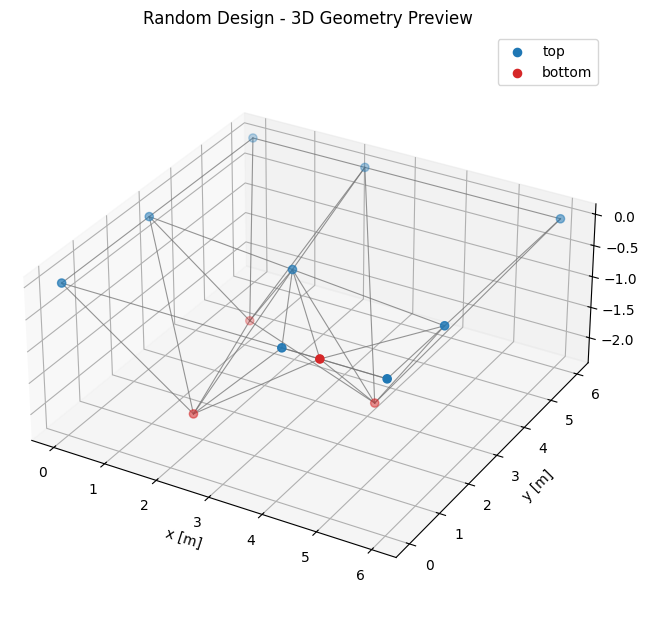

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Build a lookup so we can quickly fetch coordinates for each vertex id.
vertex_lookup = df_vertices.set_index("vertex_index")[["x", "y", "z", "layer"]].to_dict("index")

def _to_vertex_key(v):
    v_str = str(v)
    return v_str if v_str.startswith("v") else f"v{v_str}"

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

# Draw all members (edges)
for _, edge in df_edges.iterrows():
    v1 = _to_vertex_key(edge["V1"])
    v2 = _to_vertex_key(edge["V2"])

    if v1 not in vertex_lookup or v2 not in vertex_lookup:
        continue

    p1 = vertex_lookup[v1]
    p2 = vertex_lookup[v2]
    ax.plot3D(
        [p1["x"], p2["x"]],
        [p1["y"], p2["y"]],
        [p1["z"], p2["z"]],
        color="0.45",
        linewidth=0.8,
        alpha=0.75,
    )

# Draw nodes per layer for readability
df_top = df_vertices[df_vertices["layer"] == "top"]
df_bottom = df_vertices[df_vertices["layer"] == "bottom"]

ax.scatter3D(  # type: ignore
    np.asarray(df_top["x"]),
    np.asarray(df_top["y"]),
    np.asarray(df_top["z"]),
    s=35,
    c="#1f77b4",
    label="top",
)
ax.scatter3D(  # type: ignore
    np.asarray(df_bottom["x"]),
    np.asarray(df_bottom["y"]),
    np.asarray(df_bottom["z"]),
    s=35,
    c="#d62728",
    label="bottom",
)

ax.set_title("Random Design - 3D Geometry Preview")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]", labelpad=14)
ax.legend(loc="upper right")
ax.set_box_aspect((1, 1, 0.45))

# Keep extra space on the right so the z label is fully visible.
fig.subplots_adjust(left=0.06, right=0.90, bottom=0.08, top=0.93)
plt.show()

# GNN

In [5]:
import pandas as pd
import numpy as np
import json
import config
import torch
import joblib
from c21_surrogate_model import TrussEdgeGNN
from pathlib import Path

# Load pre-trained surrogate model with fallback
MODEL_PREFIX = "ID0003_LR0.001_EP100_R0.89"
model_path = config.SM_EXPORT_PATH / f"{MODEL_PREFIX}_surrogate_model.pt"

try:
    checkpoint = torch.load(model_path)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = TrussEdgeGNN(node_in_dim=checkpoint['node_in_dim'], hidden_dim=checkpoint['hidden_dim']).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    node_scaler = joblib.load(config.SM_EXPORT_PATH / f"{MODEL_PREFIX}_node_scaler.pkl")
    edge_scaler = joblib.load(config.SM_EXPORT_PATH / f"{MODEL_PREFIX}_edge_scaler.pkl")
    print(f"Model loaded on {device}")
    model_available = True
except FileNotFoundError:
    print("⚠ Model not found. Using synthetic forces (10-50 kN).")
    model_available = False

# Prepare geometry and edge index
df_geometry = df_vertices.copy()
edge_index_path = config.DATA_IO_PATH / "edge_index.json"
with open(edge_index_path, "r", encoding="utf-8") as f:
    edge_index_raw = json.load(f)

if isinstance(edge_index_raw, dict):
    start_nodes = edge_index_raw.get("start_nodes") or edge_index_raw.get("source") or edge_index_raw.get("V1")
    end_nodes = edge_index_raw.get("end_nodes") or edge_index_raw.get("target") or edge_index_raw.get("V2")
    if start_nodes is None or end_nodes is None:
        raise ValueError("edge_index.json missing required keys.")
    edge_index = [start_nodes, end_nodes]
elif isinstance(edge_index_raw, list) and len(edge_index_raw) == 2:
    edge_index = edge_index_raw
else:
    raise ValueError("Unexpected edge_index.json format.")

def get_edge_length(idx_a, idx_b):
    coord_a = df_geometry.iloc[idx_a][['x', 'y', 'z']].values.astype(float)
    coord_b = df_geometry.iloc[idx_b][['x', 'y', 'z']].values.astype(float)
    return np.linalg.norm(coord_b - coord_a)

start_nodes = edge_index[0]
end_nodes = edge_index[1]

# Run inference (real model or synthetic fallback)
if model_available:
    print("Running GNN inference...")
    
    feature_cols = ['x', 'y', 'z']
    if 'load_z' in df_geometry.columns:
        feature_cols.append('load_z')
    elif 'is_support' in df_geometry.columns:
        feature_cols.append('is_support')
    else:
        df_geometry['default_feature'] = 0.0
        feature_cols.append('default_feature')
    
    node_features_raw = df_geometry[feature_cols].values.astype(np.float32)
    scaler_in_dim = getattr(node_scaler, "n_features_in_", node_features_raw.shape[1])
    
    if node_features_raw.shape[1] < scaler_in_dim:
        pad = np.zeros((node_features_raw.shape[0], scaler_in_dim - node_features_raw.shape[1]), dtype=np.float32)
        node_features_for_scaler = np.hstack([node_features_raw, pad])
    elif node_features_raw.shape[1] > scaler_in_dim:
        node_features_for_scaler = node_features_raw[:, :scaler_in_dim]
    else:
        node_features_for_scaler = node_features_raw
    
    node_features_scaled = node_scaler.transform(node_features_for_scaler)
    model_in_dim = checkpoint["node_in_dim"]
    
    if node_features_scaled.shape[1] < model_in_dim:
        pad = np.zeros((node_features_scaled.shape[0], model_in_dim - node_features_scaled.shape[1]), dtype=np.float32)
        node_features_scaled = np.hstack([node_features_scaled, pad])
    elif node_features_scaled.shape[1] > model_in_dim:
        node_features_scaled = node_features_scaled[:, :model_in_dim]
    
    node_features_tensor = torch.from_numpy(node_features_scaled).float().to(device)
    edge_index_tensor = torch.tensor(edge_index, dtype=torch.long).to(device)
    
    with torch.no_grad():
        predictions_scaled = model(node_features_tensor, edge_index_tensor)
    
    predictions_np = predictions_scaled.detach().cpu().numpy()
    predictions_original = edge_scaler.inverse_transform(predictions_np)
    
else:
    predictions_original = np.random.uniform(10, 50, size=(len(start_nodes), 1))

# Format results as dataframe
predictions_records = []
for i in range(len(start_nodes)):
    predictions_records.append({
        "edge_id": f"e{i}",
        "V1": f"{start_nodes[i]}",
        "V2": f"{end_nodes[i]}",
        "length_m": round(get_edge_length(start_nodes[i], end_nodes[i]), 3),
        "axial_force_kn": round(float(predictions_original[i][0]), 2),
    })

df_forces = pd.DataFrame(predictions_records)
df_forces.to_csv(config.EXPORT_PATH / "predicted_forces.csv", index=False)
print(f"Forces saved for {len(df_forces)} elements")

c:\Users\Jasper\Documents\PyEnvs\thesis_home_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded on cpu
Running GNN inference...
Forces saved for 32 elements


## Utilization

In [6]:
import importlib
import structural_check
from structural_check import compute_utilization_outputs

importlib.reload(structural_check)
compute_utilization_outputs = structural_check.compute_utilization_outputs

# Validate inputs and run utilization check
required_vars = ["df_forces", "df_input_stock"]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise ValueError("Missing: " + ", ".join(missing_vars))

outputs = compute_utilization_outputs(df_forces=df_forces, df_input_stock=df_input_stock, gnn_marge=1.10)

# Unpack outputs
(df_inventory, df_forces_local, df_utilization_long, df_utilization_matrix,
 df_utilization_matrix_display, safe_options, df_slots) = (
    outputs["df_inventory"], outputs["df_forces_local"], outputs["df_utilization_long"],
    outputs["df_utilization_matrix"], outputs["df_utilization_matrix_display"],
    outputs["veilige_opties"], outputs["df_slots"]
)
veilige_opties = safe_options

# Dataset convention is depth-first, so swap slot requirements to match inventory mapping
if {"Width_Req", "Depth_Req"}.issubset(df_slots.columns):
    df_slots = df_slots.copy()
    df_slots[["Width_Req", "Depth_Req"]] = df_slots[["Depth_Req", "Width_Req"]].to_numpy()
    print("Swapped Width_Req and Depth_Req to match depth-first dataset convention")

df_slots.to_csv(config.EXPORT_PATH / "structure_slots.csv", index=False)
print(f"Utilization: {len(df_forces_local)} members, {len(df_inventory)} stock -> {len(safe_options)} safe combinations")

Swapped Width_Req and Depth_Req to match depth-first dataset convention
Utilization: 32 members, 324 stock -> 9540 safe combinations


# COST MATRIX

We now use one universal assignment formula for both reclaimed and new timber in the same cost matrix:

$$C_{i,j} = E_{embodied,i} + E_{prep,i} + E_{trans,i,j} + E_{waste,i,j} + E_{saw,i,j}$$

With:
- $E_{embodied,i} = V_{stock,i} \cdot M_{material,i}$ (from `ECC` in stock data)
- $E_{prep,i} = V_{stock,i} \cdot E_{prep}$
- $E_{trans,i,j} = \left(\frac{(V_{req}+V_{over})\cdot\rho}{1000}\right)\cdot D\cdot F_{trans}$
- $E_{waste,i,j} = V_{waste} \cdot E_{EoL}$
- $E_{saw,i,j} = P_{cut}$ when cutting is required, else 0

Interpretation by timber type:
- New timber: typically high `ECC`, usually low/zero preparation factor
- Reclaimed timber: `ECC` near 0, non-zero preparation factor

## Building of cost matrix

In [16]:
import importlib
import io
import contextlib
import numpy as np
import pandas as pd
import config
import cost_calculation as cc

importlib.reload(cc)
build_cost_matrix = cc.build_cost_matrix
analyze_and_export_slot_logs = cc.analyze_and_export_slot_logs

# Cost matrix settings
target_slot_for_analysis = 'e24'
all_stock_ids = df_input_stock['Member_ID'].dropna().astype(str).tolist()
utilization_threshold = 1.25
utilization_threshold_sweep = [1.00, 1.25, 1.50]
utilization_matrix_for_cost = df_utilization_matrix if 'df_utilization_matrix' in globals() else None

# Show threshold sweep table
if utilization_matrix_for_cost is not None:
    sweep_rows = []
    for thr in utilization_threshold_sweep:
        with contextlib.redirect_stdout(io.StringIO()):
            cm_s, _, _ = build_cost_matrix(
                df_slots,
                df_input_stock,
                target_stock_ids=None,
                df_utilization_matrix=utilization_matrix_for_cost,
                max_utilization_threshold=thr,
            )
        fm = np.isfinite(cm_s)
        vc = int(fm.sum())
        tc = int(cm_s.size)
        mc = float(np.nanmean(np.where(fm, cm_s, np.nan))) if vc > 0 else np.nan
        sweep_rows.append(
            {
                'threshold': thr,
                'valid': vc,
                'total': tc,
                'ratio': round(vc / tc if tc > 0 else 0, 4),
                'mean_cost': round(mc, 2) if np.isfinite(mc) else np.nan,
            }
        )

    df_threshold_sweep = pd.DataFrame(sweep_rows)
    display(df_threshold_sweep)

# Build final cost matrix
with contextlib.redirect_stdout(io.StringIO()):
    cost_matrix, enriched_stock, df_logs = build_cost_matrix(
        df_slots,
        df_input_stock,
        target_stock_ids=all_stock_ids,
        df_utilization_matrix=utilization_matrix_for_cost,
        max_utilization_threshold=utilization_threshold,
    )

df_cost_matrix_display = pd.DataFrame(
    cost_matrix,
    index=[f"{row['edge_id']}" for _, row in df_slots.iterrows()],
    columns=enriched_stock['Member_ID'].tolist(),
)
df_cost_matrix_display.to_csv(config.EXPORT_PATH / 'final_cost_matrix.csv', index=True)

# Show compact cost matrix preview
display(df_cost_matrix_display.iloc[:8, :5].round(2))

# Keep detailed export but suppress narrative output in notebook
with contextlib.redirect_stdout(io.StringIO()):
    df_logs_slot, df_logs_slot_rs, analysis_export_path = analyze_and_export_slot_logs(
        df_logs=df_logs,
        target_slot_for_analysis=target_slot_for_analysis,
        all_stock_ids=all_stock_ids,
        export_dir=config.EXPORT_PATH,
        display_fn=None,
        max_full_list_rows=None,
        show_full_list=False,
    )

,threshold,valid,total,ratio,mean_cost
0,1.00,3918,10368,0.3779,12.83
1,1.25,3941,10368,0.3801,12.79
2,1.50,3955,10368,0.3815,12.77


,threshold,valid,total,ratio,mean_cost
0,1.00,3918,10368,0.3779,12.83
1,1.25,3941,10368,0.3801,12.79
2,1.50,3955,10368,0.3815,12.77


,NS_00000,NS_00001,NS_00002,NS_00003,NS_00004
e0,inf,inf,inf,inf,inf
e1,inf,inf,inf,inf,inf
e2,inf,inf,inf,inf,inf
e3,inf,inf,inf,inf,inf
e4,inf,inf,inf,inf,inf
e5,inf,inf,inf,inf,inf
e6,inf,inf,inf,inf,inf
e7,inf,inf,inf,inf,inf


In [9]:
# Verify dimension columns exist
inv_dims = [col for col in df_input_stock.columns if col.lower() in ['width', 'depth', 'length']]
slot_reqs = [col for col in df_slots.columns if 'Req' in col]
print(f"Inventory dims: {inv_dims} | Slot reqs: {slot_reqs}")

Inventory dims: ['Length', 'Depth', 'Width'] | Slot reqs: ['Length_Req', 'Width_Req', 'Depth_Req', 'Utilization_Req']


# MATCHING ALGORITHM / MILP

The assignment problem in this notebook is solved as a mixed-integer linear program (MILP). Let:

- $I$ be the set of required structural slots,
- $J$ be the set of inventory stock elements,
- $F \subseteq I \times J$ be the set of physically feasible slot-stock combinations,
- $R \subseteq J$ be the subset of reclaimed timber,
- $N \subseteq J$ be the subset of new timber,
- $c_{ij}$ be the cost of assigning stock element $j$ to slot $i$,
- $x_{ij} \in \{0,1\}$ be the decision variable, where $x_{ij}=1$ means that stock element $j$ is assigned to slot $i$.

$$
\min_{x} \sum_{(i,j) \in F} c_{ij} x_{ij}
$$

subject to

$$
\sum_{j:(i,j)\in F} x_{ij} = 1 \qquad \forall i \in I
$$

$$
\sum_{i:(i,j)\in F} x_{ij} \le 1 \qquad \forall j \in R
$$

$$
\sum_{i:(i,j)\in F} x_{ij} \le |I| \qquad \forall j \in N
$$

$$
x_{ij} = 0 \qquad \forall (i,j) \notin F
$$

In words: every structural member must receive exactly one feasible timber element, reclaimed timber can be used at most once, and new timber can be reused when physically feasible.

In [10]:
import pulp
import numpy as np
import pandas as pd

print("Starting MILP optimizer...")

# Extract feasible combinations
stock_items = enriched_stock['Member_ID'].tolist()
construction_slots = df_slots['edge_id'].tolist()
new_items = [item for item in stock_items if 'NS' in item]
reclaimed_items = [item for item in stock_items if 'RS' in item]

print(f"MILP setup: {len(reclaimed_items)} reclaimed + {len(new_items)} new → {len(construction_slots)} slots")

# Extract finite cost matrix positions
finite_positions = np.argwhere(np.isfinite(cost_matrix))
valid_matches = []
costs = {}
slot_to_stocks = {sid: [] for sid in construction_slots}
stock_to_slots = {sid: [] for sid in stock_items}

for i, j in finite_positions:
    sid, jid = construction_slots[int(i)], stock_items[int(j)]
    match = (jid, sid)
    valid_matches.append(match)
    costs[match] = float(cost_matrix[int(i), int(j)])
    slot_to_stocks[sid].append(jid)
    stock_to_slots[jid].append(sid)

# Check feasibility
infeasible_slots = [sid for sid, opts in slot_to_stocks.items() if not opts]
if infeasible_slots:
    print(f"ERROR: {len(infeasible_slots)} slots infeasible: {infeasible_slots[:5]}")
    raise ValueError("MILP aborted: infeasible slots exist")

# Setup and solve
prob = pulp.LpProblem("Timber_Matching", pulp.LpMinimize)
x = pulp.LpVariable.dicts("Match", valid_matches, lowBound=0, upBound=1, cat=pulp.LpBinary)
prob += pulp.lpSum(x[m] * costs[m] for m in valid_matches)

for sid, opts in slot_to_stocks.items():
    prob += pulp.lpSum(x[(jid, sid)] for jid in opts) == 1
for jid in reclaimed_items:
    if jid in stock_to_slots:
        prob += pulp.lpSum(x[(jid, sid)] for sid in stock_to_slots[jid]) <= 1
for jid in new_items:
    if jid in stock_to_slots:
        prob += pulp.lpSum(x[(jid, sid)] for sid in stock_to_slots[jid]) <= len(construction_slots)

pulp.PULP_CBC_CMD(msg=False).solve(prob)
print(f"\nMILP Status: {pulp.LpStatus[prob.status]}")

if pulp.LpStatus[prob.status] == 'Optimal':
    total_cost = pulp.value(prob.objective)
    results = [{'edge_id': sid, 'assigned_timber': jid, 'CO2_Penalty': round(costs[(jid, sid)], 2)}
              for jid, sid in valid_matches if x[(jid, sid)].varValue == 1]
    df_results = pd.DataFrame(results)
    print(f"Optimal solution: {total_cost:.2f} kg CO2e for {len(df_results)} assignments")
    df_results.to_csv(config.EXPORT_PATH / "final_results.csv", index=False)
else:
    print("No optimal solution found. Inventory may be insufficient.")

Starting MILP optimizer...
MILP setup: 18 reclaimed + 306 new → 32 slots
ERROR: 4 slots infeasible: ['e0', 'e9', 'e30', 'e31']


ValueError: MILP aborted: infeasible slots exist

# EXPORT

Exports structural parameters (vertices + edges with assigned timber) for Grasshopper reconstruction.

In [ ]:
# Export geometry + matching results
import pandas as pd
import config

EXPORT_PREFIX = "optimum"
required_vars = ["df_vertices", "df_edges", "df_results"]
if any(name not in globals() for name in required_vars):
    raise ValueError(f"Missing: {', '.join(required_vars)}")

df_edges_export = pd.merge(df_edges, df_results[["edge_id", "assigned_timber", "CO2_Penalty"]], on="edge_id", how="left")
df_edges_export["assigned_timber"] = df_edges_export["assigned_timber"].fillna("UNASSIGNED")
df_edges_export["CO2_Penalty"] = df_edges_export["CO2_Penalty"].fillna(0)

df_vertices.to_csv(config.EXPORT_PATH / f"{EXPORT_PREFIX}_vertices.csv", index=False)
df_edges_export.to_csv(config.EXPORT_PATH / f"{EXPORT_PREFIX}_edges_with_stock.csv", index=False)
n_matched = int((df_edges_export["assigned_timber"] != "UNASSIGNED").sum())
print(f"Exported: {len(df_vertices)} vertices, {len(df_edges_export)} edges ({n_matched} matched)")

# MULTI-OBJECTIVE FITNESS EVALUATION

## Overview

The fitness function balances three competing objectives:

$$F(\mathbf{x}) = \omega_1 \left( \frac{f_{inner}^*(\mathbf{x})}{\mathcal{C}_{max}} \right) - \omega_2 \left( \frac{\mathcal{R}(\mathbf{x}, \mathbf{y}^*)}{\mathcal{R}_{max}} \right) + \omega_3 \left( \frac{\mathcal{W}(\mathbf{x}, \mathbf{y}^*)}{\mathcal{W}_{max}} \right)$$

**Components:**
- **$f_{inner}^*$**: MILP cost (kg CO2e) — penalizes virgin material and waste
- **$\mathcal{R}$**: Reuse rate (%) — reward for using reclaimed timber (subtracted, so higher reuse = better)
- **$\mathcal{W}$**: Total waste (m³) — penalizes inefficient cutting
- **$\omega_i$**: Weight coefficients to tune priorities

**Normalization constants** (precomputed from dataset extremes):
- $\mathcal{C}_{max}$ = 8.0 kg CO2e (worst-case: all virgin + max waste)
- $\mathcal{R}_{max}$ = 100% (best-case: full reclaimed timber recovery)
- $\mathcal{W}_{max}$ = 0.4 m³ (worst-case waste volume)

**Sign convention:**
- Positive coefficient on cost: higher MILP cost → higher (worse) fitness
- **Negative** coefficient on reuse: higher reuse rate → **lower (better)** fitness ✓
- Positive coefficient on waste: higher waste → higher (worse) fitness

**Fitness interpretation:**
- Lower fitness value = better design (objective to minimize)
- Negative fitness indicates strong reuse benefit outweighing cost penalties
- Positive fitness indicates cost/waste penalties dominate

In [ ]:
# Compute real fitness score
import pandas as pd
import numpy as np
import json
from fitness_aggregation import evaluate_milp_solution, print_fitness_breakdown

# Fitness configuration
WEIGHT_CONFIG = {'omega_1': 1.0, 'omega_2': 0.5, 'omega_3': 0.5, 'strategy': 'cost-dominant'}

# Validate inputs
required = {'df_results', 'enriched_stock', 'df_slots', 'total_cost'}
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Missing: {', '.join(missing)}")

print(f"Computing fitness (strategy: {WEIGHT_CONFIG['strategy']})...")

# Evaluate multi-objective fitness
fitness_result = evaluate_milp_solution(
    milp_results_df=df_results, enriched_stock_df=enriched_stock,
    df_slots=df_slots, milp_objective_value=total_cost,
    weights=(WEIGHT_CONFIG['omega_1'], WEIGHT_CONFIG['omega_2'], WEIGHT_CONFIG['omega_3']))

print_fitness_breakdown(fitness_result)

# Export results
fitness_json_path = config.EXPORT_PATH / "fitness_result.json"
fitness_csv_path = config.EXPORT_PATH / "fitness_result.csv"

with open(fitness_json_path, 'w') as f:
    fitness_export = {k: (float(v) if isinstance(v, (np.floating, np.integer)) else v) for k, v in fitness_result.items()}
    json.dump(fitness_export, f, indent=2)

fitness_df = pd.DataFrame([{**fitness_result, **WEIGHT_CONFIG}])
fitness_df.to_csv(fitness_csv_path, index=False)
print(f"Fitness result exported to {fitness_csv_path}")